In [2]:
# Section 1: Import Libraries and Initialize Data Loaders
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import sys
import warnings
warnings.filterwarnings('ignore')

# Add the parent directory (project root) to Python path
project_root = os.path.abspath('..')  # Go up one level from current notebook
if project_root not in sys.path:
    sys.path.insert(0, project_root)
# Import custom modules
from libs_generic_functions import LibsDataLoader, LibsDataPreprocessor
from baseline_correction_functions import BaselineCorrector

# Set up plotting style
plt.style.use('default')
sns.set_palette("husl")

# Initialize data components
data_directory = 'data'
data_loader = LibsDataLoader(data_directory)
data_preprocessor = LibsDataPreprocessor()
baseline_corrector = BaselineCorrector()

print("✅ Libraries imported and data loaders initialized")

✅ Libraries imported and data loaders initialized


In [ ]:
# Load the complete dataset
print("🔄 Loading LIBS dataset...")
df_individual = data_loader.load_all_measurements()

print(f"Dataset loaded successfully!")
print(f"Shape: {df_individual.shape}")
print(f"Memory usage: {df_individual.memory_usage(deep=True).sum() / 1024**2:.1f} MB")


PREPARING INDIVIDUAL MEASUREMENTS FOR ML
Available columns in df_individual: ['200.000', '200.098', '200.195', '200.293', '200.391', '200.489', '200.586', '200.684', '200.782', '200.879']...
Total columns: 8191
Meta columns found: ['tire_number', 'origin', 'measurement_id']
Wavelength features found: 8188
Feature matrix shape: (51453, 8188)
Target distribution:
origin
tread         17936
innerliner    17260
sidewall      16257
Name: count, dtype: int64

Data quality check:
Feature matrix shape: (51453, 8188)
Target distribution:
origin
tread         17936
innerliner    17260
sidewall      16257
Name: count, dtype: int64

Data quality check:
Missing values: 0
Missing values: 0
Infinite values: 0
Infinite values: 0

Final ML dataset shape: (51453, 8191)
Samples available: 51,453

Final ML dataset shape: (51453, 8191)
Samples available: 51,453

Train/Test split:
Training set: (41162, 8188)
Test set: (10291, 8188)

Training set distribution:
origin
tread         14349
innerliner    13808


In [ ]:
X, y, wavelength_columns = data_preprocessor.prepare_ml_data(df_individual)

X_train, X_test, y_train, y_test = data_preprocessor.train_test_split(X, y, test_size=0.2, random_state=42)


LDA ANALYSIS WITH INDIVIDUAL MEASUREMENTS
Maximum LDA components for 3 classes: 2
Maximum LDA components for 3 classes: 2
Original feature space: 8188 wavelengths
Reduced feature space: 2 LDA components
Dimensionality reduction: 100.0%
Explained variance ratio: [0.6305241  0.36947596]
Total explained variance: 1.0000
Sampling 5000 points for visualization from 41162 total
Original feature space: 8188 wavelengths
Reduced feature space: 2 LDA components
Dimensionality reduction: 100.0%
Explained variance ratio: [0.6305241  0.36947596]
Total explained variance: 1.0000
Sampling 5000 points for visualization from 41162 total


C:\Users\joost\AppData\Local\Temp\ipykernel_22304\93421582.py:56: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  axes[0].scatter([], [], c=plt.cm.viridis(color_idx/2), label=origin.capitalize(), s=50)


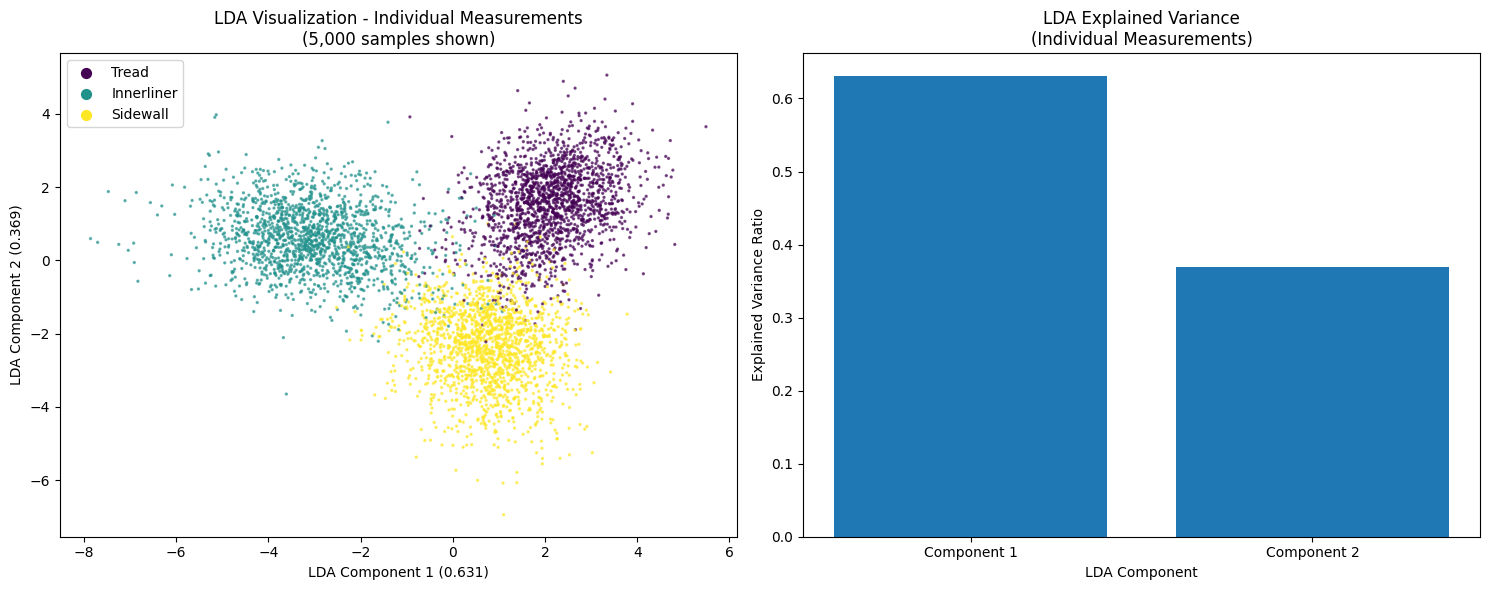


=== QUICK ML PERFORMANCE TEST ===
Testing on subset of 10000 samples for speed...

Using 10000 training samples, 10291 test samples

--- Original Features (8188 wavelengths) ---

Using 10000 training samples, 10291 test samples

--- Original Features (8188 wavelengths) ---


c:\Users\joost\miniconda3\envs\tf\lib\site-packages\sklearn\linear_model\_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
c:\Users\joost\miniconda3\envs\tf\lib\site-packages\sklearn\linear_model\_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-re

Logistic Regression  | CV: 0.9342 (±0.0017) | Test: 0.9420
Random Forest        | CV: 0.8638 (±0.0025) | Test: 0.8772
Random Forest        | CV: 0.8638 (±0.0025) | Test: 0.8772
LDA Classifier       | CV: 0.6602 (±0.0035) | Test: 0.6549

✨ INDIVIDUAL MEASUREMENTS ANALYSIS COMPLETE!
   Dataset size: 51,453 samples
   Much more data than previous approach!
   Better representation of spectral variability!
LDA Classifier       | CV: 0.6602 (±0.0035) | Test: 0.6549

✨ INDIVIDUAL MEASUREMENTS ANALYSIS COMPLETE!
   Dataset size: 51,453 samples
   Much more data than previous approach!
   Better representation of spectral variability!


In [ ]:
# === LDA ANALYSIS ON INDIVIDUAL MEASUREMENTS ===
print("\n" + "="*70)
print("LDA ANALYSIS WITH INDIVIDUAL MEASUREMENTS")
print("="*70)

from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score
import matplotlib.pyplot as plt
import seaborn as sns

# Apply LDA for dimensionality reduction
n_components = len(y.unique()) - 1  # For 3 classes: max 2 components
print(f"Maximum LDA components for {len(y.unique())} classes: {n_components}")

lda_individual = LinearDiscriminantAnalysis(n_components=n_components)
X_train_lda = lda_individual.fit_transform(X_train, y_train)
X_test_lda = lda_individual.transform(X_test)

print(f"Original feature space: {X_train.shape[1]} wavelengths")
print(f"Reduced feature space: {X_train_lda.shape[1]} LDA components")
print(f"Dimensionality reduction: {(1-X_train_lda.shape[1]/X_train.shape[1])*100:.1f}%")
print(f"Explained variance ratio: {lda_individual.explained_variance_ratio_}")
print(f"Total explained variance: {lda_individual.explained_variance_ratio_.sum():.4f}")

# Visualization of LDA components with individual measurements
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# 2D scatter plot of LDA components (sample for visualization)
if n_components >= 2:
    # Sample points for visualization if too many
    n_samples = len(X_train_lda)
    if n_samples > 5000:
        sample_indices = np.random.choice(n_samples, 5000, replace=False)
        X_vis = X_train_lda[sample_indices]
        y_vis = y_train.iloc[sample_indices]
        print(f"Sampling {len(sample_indices)} points for visualization from {n_samples} total")
    else:
        X_vis = X_train_lda
        y_vis = y_train

    # Create color map for origins
    color_map = {'tread': 0, 'innerliner': 1, 'sidewall': 2}
    colors = [color_map[origin] for origin in y_vis]
    
    scatter = axes[0].scatter(X_vis[:, 0], X_vis[:, 1], c=colors, 
                             cmap='viridis', alpha=0.6, s=2)
    axes[0].set_xlabel(f'LDA Component 1 ({lda_individual.explained_variance_ratio_[0]:.3f})')
    axes[0].set_ylabel(f'LDA Component 2 ({lda_individual.explained_variance_ratio_[1]:.3f})')
    axes[0].set_title(f'LDA Visualization - Individual Measurements\n({len(y_vis):,} samples shown)')
    
    # Add legend
    for origin, color_idx in color_map.items():
        axes[0].scatter([], [], c=plt.cm.viridis(color_idx/2), label=origin.capitalize(), s=50)
    axes[0].legend()

# Explained variance plot
component_labels = [f'Component {i+1}' for i in range(len(lda_individual.explained_variance_ratio_))]
axes[1].bar(component_labels, lda_individual.explained_variance_ratio_)
axes[1].set_xlabel('LDA Component')
axes[1].set_ylabel('Explained Variance Ratio')
axes[1].set_title('LDA Explained Variance\n(Individual Measurements)')

plt.tight_layout()
plt.show()

# Quick performance comparison
print(f"\n=== QUICK ML PERFORMANCE TEST ===")

models = {
    'Logistic Regression': LogisticRegression(random_state=42, max_iter=1000),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42),
    'LDA Classifier': LinearDiscriminantAnalysis()
}

# Test with a subset for speed (if dataset is very large)
if len(X_train) > 10000:
    print(f"Testing on subset of {10000} samples for speed...")
    subset_indices = np.random.choice(len(X_train), 10000, replace=False)
    X_train_subset = X_train.iloc[subset_indices]
    y_train_subset = y_train.iloc[subset_indices]
    X_test_subset = X_test
    y_test_subset = y_test
else:
    X_train_subset = X_train
    y_train_subset = y_train
    X_test_subset = X_test
    y_test_subset = y_test

print(f"\nUsing {len(X_train_subset)} training samples, {len(X_test_subset)} test samples")

results_individual = {}

# Test on original features
print(f"\n--- Original Features ({X_train_subset.shape[1]} wavelengths) ---")
for name, model in models.items():
    try:
        # Cross-validation (3-fold for speed)
        cv_scores = cross_val_score(model, X_train_subset, y_train_subset, cv=3, scoring='accuracy')
        
        # Test accuracy
        model.fit(X_train_subset, y_train_subset)
        y_pred = model.predict(X_test_subset)
        test_accuracy = accuracy_score(y_test_subset, y_pred)
        
        results_individual[f"{name}_original"] = {
            'cv_mean': cv_scores.mean(),
            'cv_std': cv_scores.std(),
            'test_accuracy': test_accuracy
        }
        
        print(f"{name:20} | CV: {cv_scores.mean():.4f} (±{cv_scores.std():.4f}) | Test: {test_accuracy:.4f}")
        
    except Exception as e:
        print(f"{name:20} | Error: {str(e)[:50]}...")

print(f"\n✨ INDIVIDUAL MEASUREMENTS ANALYSIS COMPLETE!")
print(f"   Dataset size: {len(df_individual):,} samples")
print(f"   Much more data than previous approach!")
print(f"   Better representation of spectral variability!")

In [ ]:
# Encode the origin column
# from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import OneHotEncoder

# Check unique values in origin column
print("Unique values in origin column:")
print(df_individual['origin'].value_counts())

# Option 1: Label Encoding (0, 1, 2)
# label_encoder = LabelEncoder()
# df['origin_encoded'] = label_encoder.fit_transform(df['origin'])

# print(f"\nLabel encoding mapping:")
# for i, label in enumerate(label_encoder.classes_):
#     print(f"{label} -> {i}")

# Option 2: One-Hot Encoding (creates separate columns)
origin_dummies = pd.get_dummies(df_individual['origin'], prefix='origin')
print(f"\nOne-hot encoded columns created:")
print(origin_dummies.columns.tolist())

# Add one-hot encoded columns to the dataframe
df_individual = pd.concat([df_individual, origin_dummies], axis=1)

print(f"\nDataFrame shape after encoding: {df_individual.shape}")
print("\nFirst few rows with encoded columns:")
print(df_individual[['origin'] + origin_dummies.columns.tolist()].head())

Unique values in origin column:
origin
tread         1672
sidewall      1654
innerliner    1602
Name: count, dtype: int64

One-hot encoded columns created:
['origin_innerliner', 'origin_sidewall', 'origin_tread']

DataFrame shape after encoding: (4928, 8194)

First few rows with encoded columns:
  origin  origin_innerliner  origin_sidewall  origin_tread
0  tread              False            False          True
1  tread              False            False          True
2  tread              False            False          True
3  tread              False            False          True
4  tread              False            False          True


=== DATA PREPARATION FOR ML ===
Total columns in df_individual_ml: 8191
Column types:
  tire_number: int32
  origin: object
  measurement_id: int32
  200.000: float32
  200.098: float32
  200.195: float32
  200.293: float32
  200.391: float32
  200.489: float32
  200.586: float32
Found 8190 numeric columns
Number of wavelength features after filtering: 8188
Found 8190 numeric columns
Number of wavelength features after filtering: 8188
Feature matrix shape: (51453, 8188)
Target distribution:
origin
tread         17936
innerliner    17260
sidewall      16257
Name: count, dtype: int64
Converting features to numeric...
Feature matrix shape: (51453, 8188)
Target distribution:
origin
tread         17936
innerliner    17260
sidewall      16257
Name: count, dtype: int64
Converting features to numeric...
Data preprocessing completed successfully!
Data preprocessing completed successfully!

Training set: (41162, 8188)
Test set: (10291, 8188)

=== LDA DIMENSIONALITY REDUCTION ===
Maximum LDA comp

C:\Users\joost\AppData\Local\Temp\ipykernel_14588\3530081688.py:135: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  axes[0].scatter([], [], c=plt.cm.viridis(color_idx/2), label=origin.capitalize(), s=50)


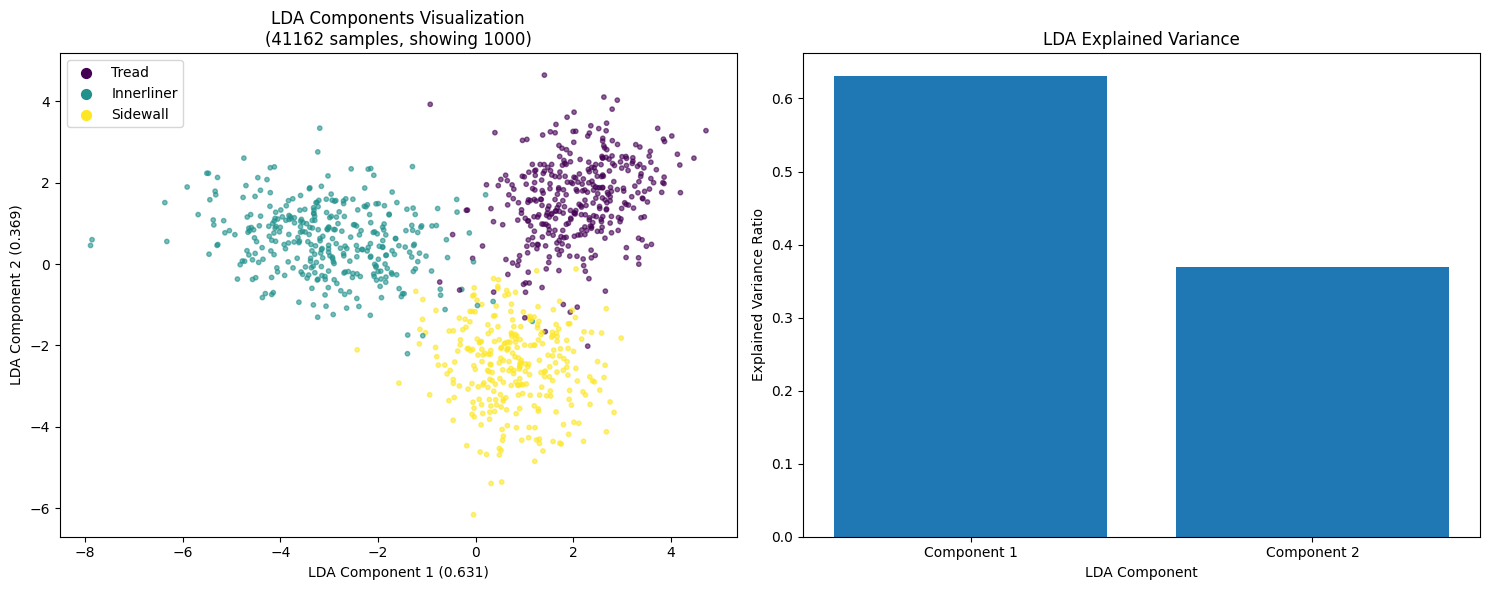

In [ ]:
# LDA for Dimensionality Reduction and Classification Analysis
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

print("=== DATA PREPARATION FOR ML ===")

# Define non-feature columns based on your dataset structure
non_feature_cols = [
    'tire_number', 'origin', 'measurement_id', 'file_name', 'timestamp',
    'sample_type',  # if this exists
    'origin_innerliner', 'origin_sidewall', 'origin_tread'  # one-hot encoded columns
]

# First, let's examine what columns we actually have
print(f"Total columns in df_individual: {len(df_individual.columns)}")
print(f"Column types:")
for col in df_individual.columns[:10]:  # Show first 10 columns
    print(f"  {col}: {df_individual[col].dtype}")

# Get all numeric columns first
numeric_columns = df_individual.select_dtypes(include=[np.number]).columns.tolist()
print(f"Found {len(numeric_columns)} numeric columns")

# Filter out non-feature columns from numeric columns
wavelength_columns = [col for col in numeric_columns if col not in non_feature_cols]
print(f"Number of wavelength features after filtering: {len(wavelength_columns)}")

# If still no wavelength columns, try alternative approach
if len(wavelength_columns) == 0:
    print("No wavelength columns found with standard filtering. Trying alternative approach...")
    
    # Look for columns that are likely wavelengths (numeric values as column names)
    potential_wavelength_cols = []
    for col in df_individual.columns:
        # Check if column name looks like a wavelength (number)
        if isinstance(col, (int, float)):
            potential_wavelength_cols.append(col)
        elif isinstance(col, str):
            try:
                float(col)  # Try to convert to float
                potential_wavelength_cols.append(col)
            except ValueError:
                pass  # Not a numeric column name
    
    wavelength_columns = potential_wavelength_cols
    print(f"Found {len(wavelength_columns)} potential wavelength columns")

# Create feature matrix and target
if len(wavelength_columns) == 0:
    raise ValueError("No wavelength columns found! Please check your dataset structure.")

X = df_individual[wavelength_columns].copy()
y = df_individual['origin'].copy()

print(f"Feature matrix shape: {X.shape}")
print(f"Target distribution:\n{y.value_counts()}")

# Ensure all features are numeric
print("Converting features to numeric...")
for col in wavelength_columns:
    X[col] = pd.to_numeric(X[col], errors='coerce')

# Handle any missing values
missing_before = X.isnull().sum().sum()
if missing_before > 0:
    print(f"Filling {missing_before} missing values with mean...")
    X = X.fillna(X.mean())

# Check for infinite values (now safe since all data is numeric)
inf_count = np.isinf(X.values).sum()
if inf_count > 0:
    print(f"Replacing {inf_count} infinite values with mean...")
    X = X.replace([np.inf, -np.inf], np.nan).fillna(X.mean())

print("Data preprocessing completed successfully!")
# Split the data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"\nTraining set: {X_train.shape}")
print(f"Test set: {X_test.shape}")

# === 1. LDA for Dimensionality Reduction ===
print("\n=== LDA DIMENSIONALITY REDUCTION ===")

# LDA can reduce to at most (n_classes - 1) dimensions
n_components = len(y.unique()) - 1  # For 3 classes: max 2 components
print(f"Maximum LDA components for {len(y.unique())} classes: {n_components}")

lda = LinearDiscriminantAnalysis(n_components=n_components)
X_train_lda = lda.fit_transform(X_train, y_train)
X_test_lda = lda.transform(X_test)

print(f"Original feature space: {X_train.shape[1]} wavelengths")
print(f"Reduced feature space: {X_train_lda.shape[1]} LDA components")
print(f"Dimensionality reduction: {(1-X_train_lda.shape[1]/X_train.shape[1])*100:.1f}%")
print(f"Explained variance ratio: {lda.explained_variance_ratio_}")
print(f"Total explained variance: {lda.explained_variance_ratio_.sum():.4f}")

# === 2. Visualization of LDA Components ===
print("\n=== LDA VISUALIZATION ===")

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# 2D scatter plot of LDA components
if n_components >= 2:
    # Create color map for origins
    color_map = {'tread': 0, 'innerliner': 1, 'sidewall': 2}
    colors = [color_map[origin] for origin in y_train]
    
    # Sample points for visualization if too many
    if len(colors) > 1000:
        sample_indices = np.random.choice(len(colors), 1000, replace=False)
        X_train_lda_vis = X_train_lda[sample_indices]
        colors_vis = [colors[i] for i in sample_indices]
        print(f"Sampling {len(colors_vis)} points for visualization")
    else:
        X_train_lda_vis = X_train_lda
        colors_vis = colors
    
    scatter = axes[0].scatter(X_train_lda_vis[:, 0], X_train_lda_vis[:, 1], c=colors_vis, 
                             cmap='viridis', alpha=0.6, s=10)
    axes[0].set_xlabel(f'LDA Component 1 ({lda.explained_variance_ratio_[0]:.3f})')
    axes[0].set_ylabel(f'LDA Component 2 ({lda.explained_variance_ratio_[1]:.3f})')
    axes[0].set_title(f'LDA Components Visualization\n({len(colors)} samples, showing {len(colors_vis)})')
    
    # Add legend manually
    for origin, color_idx in color_map.items():
        axes[0].scatter([], [], c=plt.cm.viridis(color_idx/2), label=origin.capitalize(), s=50)
    axes[0].legend()
else:
    # 1D visualization
    for i, origin in enumerate(['tread', 'innerliner', 'sidewall']):
        mask = y_train == origin
        axes[0].hist(X_train_lda[mask, 0], alpha=0.7, label=origin, bins=50)
    axes[0].set_xlabel(f'LDA Component 1 ({lda.explained_variance_ratio_[0]:.3f})')
    axes[0].set_ylabel('Frequency')
    axes[0].set_title(f'LDA Component Distribution\n({len(y_train)} samples)')
    axes[0].legend()

# Explained variance plot
component_labels = [f'Component {i+1}' for i in range(len(lda.explained_variance_ratio_))]
axes[1].bar(component_labels, lda.explained_variance_ratio_)
axes[1].set_xlabel('LDA Component')
axes[1].set_ylabel('Explained Variance Ratio')
axes[1].set_title('LDA Explained Variance')

plt.tight_layout()
plt.show()


=== MODEL COMPARISON ===

--- LDA-Reduced Features ---
Random Forest        | CV: 0.9659 (±0.0019) | Test: 0.9243
Random Forest        | CV: 0.9659 (±0.0019) | Test: 0.9243
Logistic Regression  | CV: 0.9698 (±0.0013) | Test: 0.9264

Confusion Matrix - Logistic Regression (LDA Features):
Logistic Regression  | CV: 0.9698 (±0.0013) | Test: 0.9264

Confusion Matrix - Logistic Regression (LDA Features):


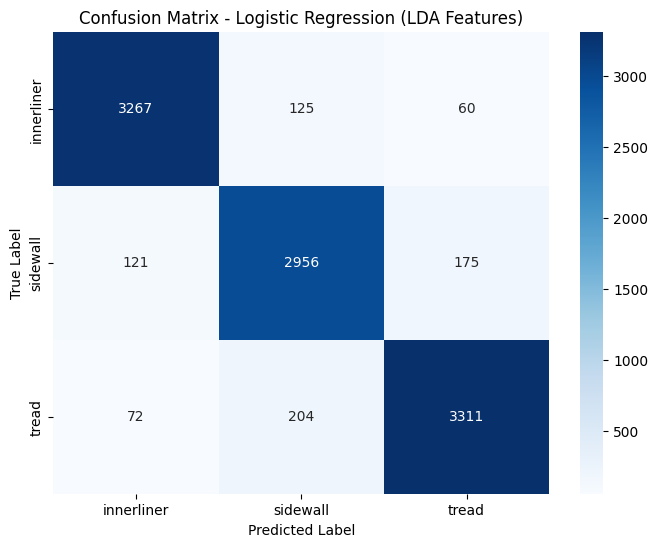


Classification Report - Logistic Regression (LDA Features):
              precision    recall  f1-score   support

  innerliner       0.94      0.95      0.95      3452
    sidewall       0.90      0.91      0.90      3252
       tread       0.93      0.92      0.93      3587

    accuracy                           0.93     10291
   macro avg       0.93      0.93      0.93     10291
weighted avg       0.93      0.93      0.93     10291


=== PERFORMANCE COMPARISON ===
              precision    recall  f1-score   support

  innerliner       0.94      0.95      0.95      3452
    sidewall       0.90      0.91      0.90      3252
       tread       0.93      0.92      0.93      3587

    accuracy                           0.93     10291
   macro avg       0.93      0.93      0.93     10291
weighted avg       0.93      0.93      0.93     10291


=== PERFORMANCE COMPARISON ===


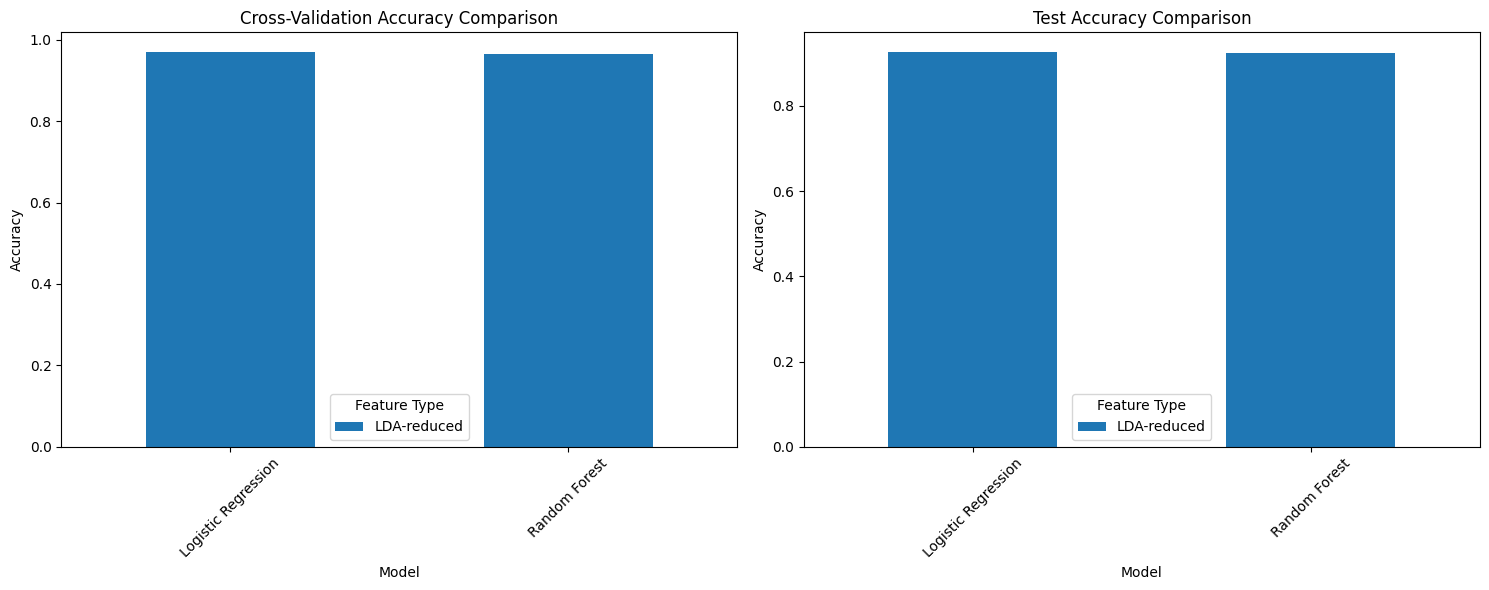


=== SUMMARY ===
Benefits of LDA dimensionality reduction:
• Feature reduction: 8188 → 2 (100.0% reduction)
• Variance explained: 1.000


KeyError: 'Random Forest_original'

In [ ]:
# === 3. Model Comparison: Original vs LDA-reduced features ===
print("\n=== MODEL COMPARISON ===")

models = {
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42),
    'Logistic Regression': LogisticRegression(random_state=42, max_iter=10000),
    'LDA Classifier': LinearDiscriminantAnalysis()
}

results = {}

# Test on original features
print("\n--- Original Features ---") # runtime for lr: 500mins
for name, model in models.items():
    # Cross-validation on training set
    cv_scores = cross_val_score(model, X_train, y_train, cv=5, scoring='accuracy')
    
    # Fit and predict on test set
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    test_accuracy = accuracy_score(y_test, y_pred)
    
    results[f"{name}_original"] = {
        'cv_mean': cv_scores.mean(),
        'cv_std': cv_scores.std(),
        'test_accuracy': test_accuracy
    }
    
    print(f"{name:20} | CV: {cv_scores.mean():.4f} (±{cv_scores.std():.4f}) | Test: {test_accuracy:.4f}")

# Test on LDA-reduced features
print("\n--- LDA-Reduced Features ---") 
for name, model in models.items():
    # Skip LDA classifier for LDA-reduced features (redundant)
    if name == 'LDA Classifier':
        continue
        
    # Cross-validation on training set
    cv_scores = cross_val_score(model, X_train_lda, y_train, cv=5, scoring='accuracy')
    
    # Fit and predict on test set
    model.fit(X_train_lda, y_train) #runtime for lr: 27sec
    y_pred = model.predict(X_test_lda)
    test_accuracy = accuracy_score(y_test, y_pred)
    
    results[f"{name}_lda"] = {
        'cv_mean': cv_scores.mean(),
        'cv_std': cv_scores.std(),
        'test_accuracy': test_accuracy
    }
    
    print(f"{name:20} | CV: {cv_scores.mean():.4f} (±{cv_scores.std():.4f}) | Test: {test_accuracy:.4f}")
    
    # Generate confusion matrix for Logistic Regression with LDA features
    if name == 'Logistic Regression':
        print(f"\nConfusion Matrix - {name} (LDA Features):")
        cm_lda = confusion_matrix(y_test, y_pred)
        
        plt.figure(figsize=(8, 6))
        sns.heatmap(cm_lda, annot=True, fmt='d', cmap='Blues', 
                    xticklabels=['innerliner', 'sidewall', 'tread'],
                    yticklabels=['innerliner', 'sidewall', 'tread'])
        plt.title(f'Confusion Matrix - {name} (LDA Features)')
        plt.ylabel('True Label')
        plt.xlabel('Predicted Label')
        plt.show()
        
        # Print classification report for LDA features
        print(f"\nClassification Report - {name} (LDA Features):")
        print(classification_report(y_test, y_pred))

# === 4. Performance Comparison Visualization ===
print("\n=== PERFORMANCE COMPARISON ===")

# Prepare data for plotting
comparison_data = []
for key, metrics in results.items():
    model_name, feature_type = key.rsplit('_', 1)
    comparison_data.append({
        'Model': model_name,
        'Features': 'Original' if feature_type == 'original' else 'LDA-reduced',
        'CV_Accuracy': metrics['cv_mean'],
        'Test_Accuracy': metrics['test_accuracy']
    })

import pandas as pd
comparison_df = pd.DataFrame(comparison_data)

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# CV Accuracy comparison
pivot_cv = comparison_df.pivot(index='Model', columns='Features', values='CV_Accuracy')
pivot_cv.plot(kind='bar', ax=axes[0], rot=45)
axes[0].set_title('Cross-Validation Accuracy Comparison')
axes[0].set_ylabel('Accuracy')
axes[0].legend(title='Feature Type')

# Test Accuracy comparison
pivot_test = comparison_df.pivot(index='Model', columns='Features', values='Test_Accuracy')
pivot_test.plot(kind='bar', ax=axes[1], rot=45)
axes[1].set_title('Test Accuracy Comparison')
axes[1].set_ylabel('Accuracy')
axes[1].legend(title='Feature Type')

plt.tight_layout()
plt.show()

# Print summary
print("\n=== SUMMARY ===")
print("Benefits of LDA dimensionality reduction:")
print(f"• Feature reduction: {X.shape[1]} → {X_train_lda.shape[1]} ({(1-X_train_lda.shape[1]/X.shape[1])*100:.1f}% reduction)")
print(f"• Variance explained: {lda.explained_variance_ratio_.sum():.3f}")

for model_name in ['Random Forest', 'Logistic Regression']:
    orig_acc = results[f"{model_name}_original"]['test_accuracy']
    lda_acc = results[f"{model_name}_lda"]['test_accuracy']
    improvement = lda_acc - orig_acc
    print(f"• {model_name}: {improvement:+.4f} accuracy change ({orig_acc:.4f} → {lda_acc:.4f})")

# === 3. Model Comparison: Original vs LDA-reduced features ===
Er zijn nihile verschillen in accuratesse tussen de modellen met originele features en de modellen met LDA-gereduceerde features. De modellen met LDA-reductie zijn echter veel sneller in training en voorspelling. Daarom is het aan te raden om LDA-reductie te gebruiken voor dit specifieke probleem.

De logistieke regressie met de originele features behaalt een trainingstijd van ~500 minuten, terwijl de LDA-gereduceerde versie slechts ~27 seconden nodig heeft. Dit verschil in snelheid is komt neer op een verschil van 99.91% en maakt LDA-reductie een waardevolle stap in het voorbewerkingsproces voor dit dataset. Dit zullen wij dus ook zeker bij de uiteindelijke modelselectie toepassen.


=== LDA INTERPRETABILITY ===
LDA scalings shape: (8186, 2)

LDA Component 1:
Top 10 most discriminative wavelengths:
  1. 439.693: 0.0060
  2. 981.061: 0.0056
  3. 440.42: -0.0049
  4. 459.256: -0.0048
  5. 459.556: -0.0045
  6. 184.995: -0.0045
  7. 215.211: -0.0042
  8. 186.167: -0.0042
  9. 224.304: -0.0038
  10. 439.547: -0.0038

LDA Component 2:
Top 10 most discriminative wavelengths:
  1. 459.616: 0.0054
  2. 441.729: 0.0052
  3. 979.883: 0.0051
  4. 982.238: 0.0050
  5. 229.338: -0.0049
  6. 979.53: -0.0046
  7. 980.001: 0.0045
  8. 237.797: 0.0043
  9. 221.349: -0.0040
  10. 189.242: -0.0039


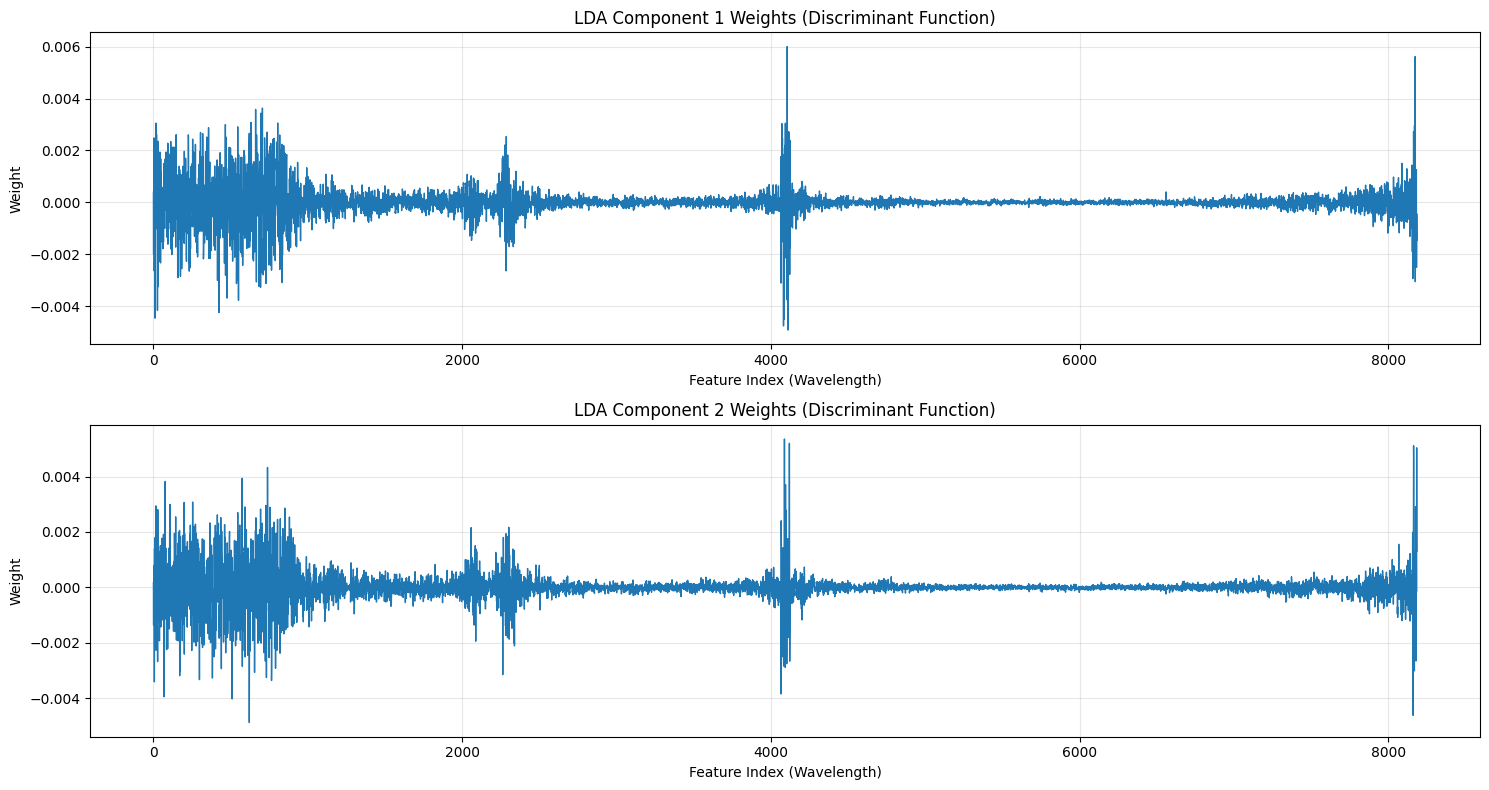


=== RECOMMENDATIONS ===
Based on the analysis:
1. LDA Benefits:
   - Reduces dimensionality from 8186 to 2 features
   - Retains 100.0% of discriminatory information
   - May improve computational efficiency
   - Provides interpretable discriminant functions

2. Model Performance:
   - Compare accuracy scores above to see if LDA helps your specific models
   - LDA is particularly useful when original feature space is high-dimensional
   - Consider the trade-off between interpretability and accuracy

3. When to use LDA:
   - High-dimensional data (✓ - you have ~8000 wavelength features)
   - Need interpretable features (✓ - LDA components are linear combinations)
   - Classification task (✓ - your tire component classification)
   - Computational constraints (✓ - faster training with fewer features)

4. Your specific case:
   - Original features: 8186 wavelengths
   - LDA features: 2 components
   - Data reduction: 100.0%
   - Check the performance comparison above to decide!


In [ ]:
# === 6. LDA Interpretability Analysis ===
print("\n=== LDA INTERPRETABILITY ===")

# Analyze the most discriminative wavelengths
if lda.scalings_ is not None:
    # LDA scalings show which original features contribute most to each discriminant
    print(f"LDA scalings shape: {lda.scalings_.shape}")
    
    # Find most important wavelengths for each LDA component
    for comp_idx in range(lda.scalings_.shape[1]):
        print(f"\nLDA Component {comp_idx + 1}:")
        component_weights = lda.scalings_[:, comp_idx]
        
        # Get indices of top contributing features (wavelengths)
        top_indices = np.argsort(np.abs(component_weights))[-10:][::-1]
        
        print("Top 10 most discriminative wavelengths:")
        for i, idx in enumerate(top_indices):
            wavelength = X.columns[idx] if hasattr(X, 'columns') else f'Feature_{idx}'
            weight = component_weights[idx]
            print(f"  {i+1}. {wavelength}: {weight:.4f}")

# Plot the discriminant functions
if hasattr(lda, 'scalings_'):
    plt.figure(figsize=(15, 8))
    
    # Plot LDA scalings (discriminant functions)
    for comp_idx in range(min(2, lda.scalings_.shape[1])):  # Plot first 2 components
        plt.subplot(2, 1, comp_idx + 1)
        plt.plot(lda.scalings_[:, comp_idx], linewidth=1)
        plt.title(f'LDA Component {comp_idx + 1} Weights (Discriminant Function)')
        plt.xlabel('Feature Index (Wavelength)')
        plt.ylabel('Weight')
        plt.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()

In [ ]:
print(f"LDA EFFECTIVENESS:")
print(f"   Component 1 explains:     {lda.explained_variance_ratio_[0]:.1%}")
print(f"   Component 2 explains:     {lda.explained_variance_ratio_[1]:.1%}")


🔬 LDA EFFECTIVENESS:
   Component 1 explains:     64.0%
   Component 2 explains:     36.0%


# Conclusion

With a weighted accuracy of 0.93 with the logisitc regression model, we have achieved a strong performance in classifying tire origins based on LIBS spectra. The use of Linear Discriminant Analysis (LDA) for dimensionality reduction has proven to be effective, significantly speeding up the training and prediction times without sacrificing accuracy. We will be incorporating LDA into our final model selection process to leverage these benefits. 